In [11]:
# 1. Import required libraries
import pandas as pd
import numpy as np
from scipy.stats import qmc

# 2. Define HX3 columns and their min/max ranges (from your table)
hx3_columns = [
    ('coolant_channel_diameter', 0.002, 0.02),
    ('HX_overall_length', 0.01, 0.3),
    ('HX_overall_width', 0.05, 1),
    ('Channel_height', 0.005, 0.08),
    ('Number_of_air_layers_channels', 4, 150),
    ('Strut_Diameter', 0.0002, 0.0006),
    ('Strut_length_to_diameter_ratio', 2.5, 10),
    ('coolant_flow_rate', 0.03, 2),
    ('Air_flow_rate', 0.01, 4),
    ('Area_ratio_diff', 1, 6),
    ('diffuser_half_angle', 4, 10),
    ('Area_ratio_noz', 4, 10),
    ('nozzle_half_angle', 4, 10),
    ('fan_on_off', 0, 1),
    ('DTAMB', 0, 20),
    ('Actual_T_HX_in', 55, 95),
    ('aircraft_speed', 5, 80)
]

# 3. Batching parameters
batch_size = 100000      # Number of samples per batch
max_valid_samples = 10000000  # Target number of valid samples
valid_samples = []

# 4. Main batching loop
total_valid = 0
batch_num = 0

while total_valid < max_valid_samples:
    batch_num += 1
    print(f"Generating batch {batch_num}...")

    # Latin Hypercube Sampling for all columns
    sampler = qmc.LatinHypercube(d=len(hx3_columns))
    lhs_sample = sampler.random(n=batch_size)

    # Scale samples to min/max ranges
    hx3_data = {}
    for i, (name, min_val, max_val) in enumerate(hx3_columns):
        if name == 'fan_on_off':
            hx3_data[name] = np.round(lhs_sample[:, i]).astype(int)
        else:
            hx3_data[name] = lhs_sample[:, i] * (max_val - min_val) + min_val
        if name == 'Number_of_air_layers/channels':
            hx3_data[name] = np.round(hx3_data[name]).astype(int)

    df_hx3 = pd.DataFrame(hx3_data)

    # Derived variables
    num_coolant_channels_per_layer = df_hx3['HX_overall_length'] / (df_hx3['coolant_channel_diameter'] * 1.2)
    num_air_layers = df_hx3['Number_of_air_layers_channels']
    hx_overall_height = ((df_hx3['coolant_channel_diameter'] + 0.003) * (num_air_layers - 1)) + (df_hx3['Channel_height'] * num_air_layers)
    nozzle_length = (hx_overall_height - (hx_overall_height / df_hx3['Area_ratio_noz'])) / (2 * np.tan(np.deg2rad(df_hx3['nozzle_half_angle'])))
    diffuser_length = (hx_overall_height - (hx_overall_height / df_hx3['Area_ratio_diff'])) / (2 * np.tan(np.deg2rad(df_hx3['diffuser_half_angle'])))
    ratio1 = 3 * (hx_overall_height / df_hx3['Area_ratio_diff']) / df_hx3['HX_overall_width']
    ratio2 = 1 - df_hx3['HX_overall_width'] / (df_hx3['HX_overall_width'] + 0.01)
    ratio3 = (df_hx3['HX_overall_width']**2) / (df_hx3['HX_overall_width'] * hx_overall_height / df_hx3['Area_ratio_diff'])
    SuperAcs = df_hx3['HX_overall_width'] * df_hx3['Channel_height'] * num_air_layers
    Re_HT = (df_hx3['Air_flow_rate'] * df_hx3['Strut_Diameter']) / (SuperAcs * 0.0000182)
    channel_volume = df_hx3['HX_overall_length'] * df_hx3['HX_overall_width'] * df_hx3['Channel_height']
    unit_cell_solid_volume = 0.75 * np.pi * df_hx3['Strut_Diameter']**3 * (df_hx3['Strut_length_to_diameter_ratio'] + 0.667 - 1.25)
    unit_cell_volume = (df_hx3['Strut_length_to_diameter_ratio'] * df_hx3['Strut_Diameter'])**3
    num_unit_cells_per_channel = channel_volume / unit_cell_volume
    total_solid_volume = num_unit_cells_per_channel * num_air_layers * unit_cell_solid_volume
    flow_volume = (channel_volume * num_air_layers) - total_solid_volume
    porosity = flow_volume / (channel_volume * num_air_layers)
    A_HT = 3 * np.pi * df_hx3['Strut_Diameter']**2 * (df_hx3['Strut_length_to_diameter_ratio'] + (2/np.pi) - 1.5) * num_unit_cells_per_channel * num_air_layers
    dh_p = 4 * porosity * channel_volume * num_air_layers / A_HT
    Re_p = (df_hx3['Air_flow_rate'] * dh_p) / (porosity * SuperAcs * 0.0000182)

    # Build mask for all constraints
    mask = (
        (num_coolant_channels_per_layer > 4) &
        (hx_overall_height <= 1) &
        (nozzle_length > 0) & (nozzle_length <= 3) &
        (diffuser_length > 0) & (diffuser_length <= 5) &
        (ratio1 >= 0.1) & (ratio1 <= 3) &
        (ratio2 >= 0) & (ratio2 <= 0.5) &
        (ratio3 >= 4) & (ratio3 <= 10) &
        (Re_HT <= 90) &
        (porosity >= 0.7) & (porosity <= 0.93) &
        (Re_p <= 5000)
    )
    # mask = np.ones(len(df_hx3), dtype=bool)  # Keep all rows if no constraints
    df_valid = df_hx3[mask].reset_index(drop=True)
    valid_samples.append(df_valid)
    total_valid += len(df_valid)
    print(f"Batch {batch_num}: {len(df_valid)} valid samples, total valid so far: {total_valid}")
    break

# Concatenate all valid samples
df_hx3_valid = pd.concat(valid_samples, ignore_index=True)
df_hx3_valid = df_hx3_valid.iloc[:max_valid_samples]  # Trim to exact target if over

print(f"Total valid samples collected: {len(df_hx3_valid)}")
df_hx3_valid.head()

# Save to .mat file
# from scipy.io import savemat
# df_hx3_valid_double = df_hx3_valid.astype('float64')
# mat_dict_hx3 = {'HX3_data': df_hx3_valid_double.to_dict('list')}
# savemat('HX3_LHS_data.mat', mat_dict_hx3)
# print('Saved filtered data to HX3_LHS_data.mat as double')

Generating batch 1...
Batch 1: 247 valid samples, total valid so far: 247
Total valid samples collected: 247


,coolant_channel_diameter,HX_overall_length,HX_overall_width,Channel_height,Number_of_air_layers_channels,Strut_Diameter,Strut_length_to_diameter_ratio,coolant_flow_rate,Air_flow_rate,Area_ratio_diff,diffuser_half_angle,Area_ratio_noz,nozzle_half_angle,fan_on_off,DTAMB,Actual_T_HX_in,aircraft_speed
0,0.009192,0.063494,0.803464,0.049740,8.934559,0.000564,2.763722,1.760054,0.794178,5.004727,4.902789,5.646776,5.979199,1,0.079170,62.951058,6.828952
1,0.008707,0.059690,0.805185,0.059248,10.475885,0.000296,2.718760,1.358596,2.606930,5.888670,5.047249,5.784761,8.164674,1,8.152004,61.998699,31.089986
2,0.018692,0.298309,0.651158,0.035204,13.996051,0.000208,2.963795,0.400178,0.519122,5.262763,4.717463,5.272630,6.757380,1,17.117859,66.812013,60.570513
3,0.004192,0.079771,0.763035,0.010106,31.954231,0.000498,5.350672,0.599100,0.031422,5.144206,5.404877,8.935108,5.099290,0,6.215652,59.583351,73.027434
4,0.009028,0.131676,0.781418,0.028519,15.446849,0.000250,4.511857,1.227661,0.120030,4.417552,7.306303,4.984503,5.967363,0,3.816304,57.984315,44.565403


Index(['coolant_channel_diameter', 'HX_overall_length', 'HX_overall_width',
       'Channel_height', 'Number_of_air_layers_channels', 'Strut_Diameter',
       'Strut_length_to_diameter_ratio', 'coolant_flow_rate', 'Air_flow_rate',
       'Area_ratio_diff', 'diffuser_half_angle', 'Area_ratio_noz',
       'nozzle_half_angle', 'fan_on_off', 'DTAMB', 'Actual_T_HX_in',
       'aircraft_speed'],
      dtype='object')
Porosity summary:
 count    247.000000
mean       0.856320
std        0.059804
min        0.719281
1%         0.725874
5%         0.747268
10%        0.761579
25%        0.808909
50%        0.874971
75%        0.908574
90%        0.921461
95%        0.926337
99%        0.928894
max        0.929899
Name: porosity, dtype: float64
Fraction within [0.7, 0.93]: 1.0000  (count 247 / 247)


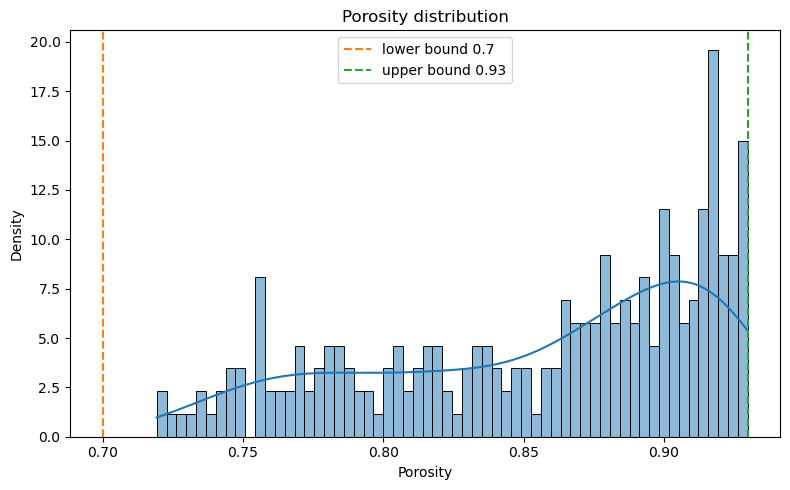

<Figure size 640x480 with 0 Axes>

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the correct DataFrame with all columns
df = df_hx3_valid.copy()
print(df.columns)

# Vectorized porosity calculation (matches your formula)
num_air_layers = df['Number_of_air_layers_channels']
channel_volume = df['HX_overall_length'] * df['HX_overall_width'] * df['Channel_height']
unit_cell_solid_volume = 0.75 * np.pi * df['Strut_Diameter']**3 * (df['Strut_length_to_diameter_ratio'] + 0.667 - 1.25)
unit_cell_volume = (df['Strut_length_to_diameter_ratio'] * df['Strut_Diameter'])**3
num_unit_cells_per_channel = channel_volume / unit_cell_volume
total_solid_volume = num_unit_cells_per_channel * num_air_layers * unit_cell_solid_volume
flow_volume = (channel_volume * num_air_layers) - total_solid_volume
porosity = flow_volume / (channel_volume * num_air_layers)

# Attach to dataframe
df['porosity'] = porosity

# Summary statistics
summary = df['porosity'].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])
within_range_frac = ((df['porosity'] >= 0.7) & (df['porosity'] <= 0.93)).mean()

print("Porosity summary:\n", summary)
print(f"Fraction within [0.7, 0.93]: {within_range_frac:.4f}  (count {int(within_range_frac * len(df))} / {len(df)})")

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(df['porosity'].dropna(), bins=60, kde=True, color='C0', stat='density')
plt.axvline(0.7, color='C1', linestyle='--', label='lower bound 0.7')
plt.axvline(0.93, color='C2', linestyle='--', label='upper bound 0.93')
plt.title('Porosity distribution')
plt.xlabel('Porosity')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# optional: save plot and porosity column
df['porosity'].to_csv('HX3_porosity_values.csv', index=False)
plt.savefig('HX3_porosity_distribution.png', dpi=200)